# Workforce Attrition Causal Analysis
## Results & Statistical Testing

---

### Notebook Goals

This notebook uses the matched dataset produced in Notebook 2 to conduct 
a valid causal comparison of attrition rates between overtime and non-overtime 
employees. Because the matched groups are balanced across all observed 
covariates, differences in attrition rates can be interpreted as evidence 
of a causal relationship rather than a spurious correlation.

---

### Approach

1. Compare attrition rates between matched groups
2. Test for statistical significance using a chi-square test
3. Quantify the effect size using relative risk and risk difference
4. Assess robustness to unmeasured confounding via sensitivity analysis
5. Summarize findings in a stakeholder-ready format

## 1. Setup & Data Loading

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


matched_df = pd.read_pickle("../data/workforce_attrition_matched.pkl")
print(f"Shape: {matched_df.shape}")
matched_df.head()

Shape: (824, 39)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Binary,OverTime_Binary,Propensity_Score,JobInvolvement_x_JobLevel,JobInvolvement_x_MonthlyIncome,Propensity_Score_v2,Pair_ID
0,45,Yes,Travel_Rarely,1449,Sales,2,3,Marketing,1277,1,...,10,1,11,1,1,0.205285,5,18824,0.141909,0
1,38,No,Travel_Frequently,240,Research & Development,2,4,Life Sciences,803,1,...,7,4,12,0,1,0.174899,8,23920,0.174515,1
2,33,No,Travel_Frequently,515,Research & Development,1,2,Life Sciences,73,1,...,14,8,12,0,1,0.176016,9,40374,0.180523,2
3,33,Yes,Travel_Frequently,1076,Research & Development,3,3,Life Sciences,702,1,...,8,9,7,1,1,0.190716,3,10044,0.187417,3
4,32,No,Travel_Rarely,427,Research & Development,1,3,Medical,78,1,...,8,7,8,0,1,0.189869,6,18486,0.190061,4


## 2. Attrition Rate Comparison

With balanced groups established through propensity score matching, we 
now compare attrition rates between overtime and non-overtime employees. 
Unlike the raw comparison in Notebook 1, this comparison is made between 
groups that are similar across all observed covariates and can be 
interpreted as causal evidence.

  OverTime  Total  Attrition_Count  Attrition_Rate
0       No    412               40        9.708738
1      Yes    412              126       30.582524


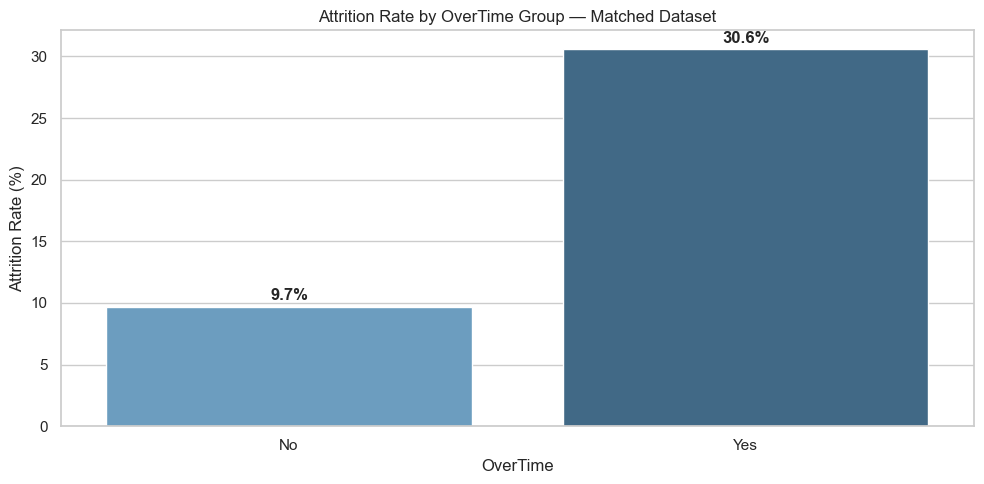

In [6]:
attrition_summary = matched_df.groupby("OverTime").agg(
    Total=("Attrition_Binary", "count"),
    Attrition_Count=("Attrition_Binary", "sum")
).reset_index()

attrition_summary["Attrition_Rate"] = (
    attrition_summary["Attrition_Count"] / attrition_summary["Total"] * 100
)

print(attrition_summary)

fig, ax = plt.subplots()
sns.barplot(
    x="OverTime",
    y="Attrition_Rate",
    data=attrition_summary,
    hue="OverTime",
    palette="Blues_d",
    legend=False,
    ax=ax
)
ax.set_title("Attrition Rate by OverTime Group — Matched Dataset")
ax.set_xlabel("OverTime")
ax.set_ylabel("Attrition Rate (%)")

for i, row in attrition_summary.iterrows():
    ax.text(i, row["Attrition_Rate"] + 0.5,
            f"{row['Attrition_Rate']:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("../outputs/10_matched_attrition_rate.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

In the matched dataset, employees who work overtime exhibit an attrition 
rate of 30.6% compared to 9.7% among matched non-overtime employees. 
This represents a difference of 20.9 percentage points between otherwise 
comparable groups.

Notably, this result is nearly identical to the raw unmatched comparison 
observed in Notebook 1 (30.5% vs 10.4%). The stability of the estimate 
across matched and unmatched comparisons suggests that the observed 
difference is not primarily driven by the confounding variables accounted 
for in the matching process, lending additional credibility to a causal 
interpretation.

We now test whether this difference is statistically significant.

## 3. Statistical Testing

We use a chi-square test of independence to assess whether the difference 
in attrition rates between matched groups is statistically significant. 
We also compute confidence intervals around each group's attrition rate 
to quantify the precision of our estimates.

In [7]:
overtime_attrition = matched_df[matched_df["OverTime"] == "Yes"]["Attrition_Binary"]
control_attrition = matched_df[matched_df["OverTime"] == "No"]["Attrition_Binary"]

contingency_table = pd.crosstab(
    matched_df["OverTime"],
    matched_df["Attrition"]
)
print("Contingency Table:")
print(contingency_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.6f}")
print(f"Degrees of Freedom: {dof}")

# Confidence intervals
ci_overtime = proportion_confint(
    overtime_attrition.sum(), len(overtime_attrition), alpha=0.05, method="wilson"
)
ci_control = proportion_confint(
    control_attrition.sum(), len(control_attrition), alpha=0.05, method="wilson"
)

print(f"\n95% Confidence Interval — OverTime: ({ci_overtime[0]*100:.1f}%, {ci_overtime[1]*100:.1f}%)")
print(f"95% Confidence Interval — No OverTime: ({ci_control[0]*100:.1f}%, {ci_control[1]*100:.1f}%)")

Contingency Table:
Attrition   No  Yes
OverTime           
No         372   40
Yes        286  126

Chi-Square Statistic: 54.5043
P-Value: 0.000000
Degrees of Freedom: 1

95% Confidence Interval — OverTime: (26.3%, 35.2%)
95% Confidence Interval — No OverTime: (7.2%, 13.0%)


### Findings

The chi-square test confirms that the difference in attrition rates between 
matched groups is statistically significant (χ² = 54.50, p < 0.001). We 
reject the null hypothesis that overtime status and attrition are independent.

The 95% confidence intervals for each group do not overlap:

- Overtime employees: 26.3% to 35.2%
- Non-overtime employees: 7.2% to 13.0%

This confirms that the observed difference is not attributable to sampling 
variability. We now quantify the magnitude of this effect using relative 
risk and risk difference.

## 4. Effect Size

Statistical significance confirms that the observed difference is unlikely 
due to chance. Effect size measures quantify the magnitude and practical 
importance of that difference.

We compute two complementary measures:

- **Risk Difference (RD)** — the absolute difference in attrition rates 
between groups, expressed in percentage points
- **Relative Risk (RR)** — the ratio of attrition rates between groups, 
expressing how many times more likely overtime employees are to leave 
relative to their matched counterparts

NameError: name 'rate_control' is not defined

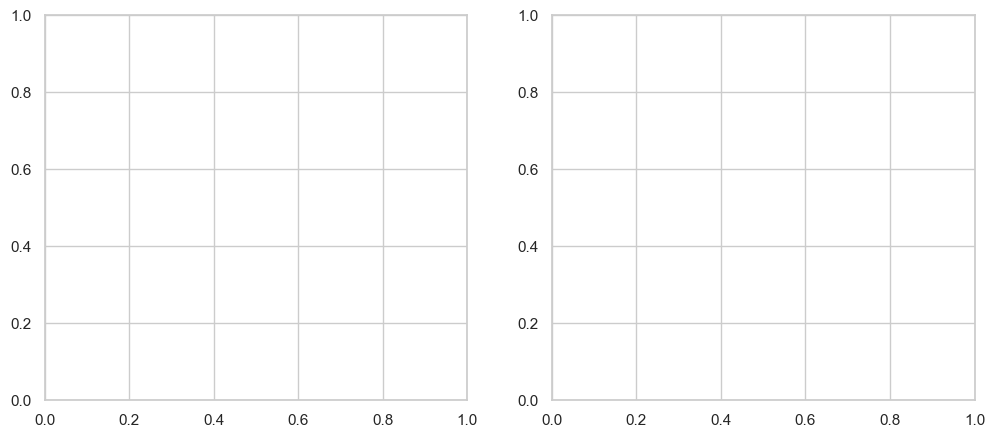

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Risk difference
categories = ["No OverTime", "OverTime"]
rates = [rate_control * 100, rate_overtime * 100]
errors = [
    [rate_control * 100 - ci_control[0] * 100, rate_overtime * 100 - ci_overtime[0] * 100],
    [ci_control[1] * 100 - rate_control * 100, ci_overtime[1] * 100 - rate_overtime * 100]
]

axes[0].bar(categories, rates, color=["steelblue", "darkblue"], alpha=0.8)
axes[0].errorbar(categories, rates, yerr=errors, fmt="none",
                 color="black", capsize=5, linewidth=1.5)
axes[0].set_title("Attrition Rate with 95% Confidence Intervals")
axes[0].set_ylabel("Attrition Rate (%)")
axes[0].set_xlabel("OverTime Group")
for i, r in enumerate(rates):
    axes[0].text(i, r + 1, f"{r:.1f}%", ha="center", fontweight="bold")

# Relative risk as scatter point
axes[1].scatter([relative_risk], [0], color="darkblue", s=200, zorder=5)
axes[1].axvline(x=1, color="red", linestyle="--", linewidth=1.5, label="RR = 1 (No Effect)")
axes[1].set_xlim(0, relative_risk + 1)
axes[1].set_ylim(-1, 1)
axes[1].set_yticks([])
axes[1].set_title("Relative Risk of Attrition — OverTime vs No OverTime")
axes[1].set_xlabel("Relative Risk")
axes[1].annotate(f"{relative_risk:.2f}x", xy=(relative_risk, 0),
                 xytext=(relative_risk + 0.1, 0.2), fontweight="bold", fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/11_effect_size.png", dpi=150, bbox_inches="tight")
plt.show()

### Findings

The effect size measures confirm a large and practically meaningful 
impact of overtime on employee attrition:

- **Risk Difference:** Overtime employees are 20.9 percentage points 
more likely to leave than their matched non-overtime counterparts
- **Relative Risk:** Overtime employees are 3.15 times more likely 
to leave than comparable employees who do not work overtime

Both measures consistently point to overtime as a strong driver of 
attrition. The magnitude of the effect — a tripling of attrition risk — 
represents a substantial organizational cost when accounting for 
recruitment, onboarding, and productivity loss associated with turnover.

We now assess the robustness of this finding to potential unmeasured 
confounding through sensitivity analysis.

## 5. Sensitivity Analysis

Propensity score matching controls for observed confounding variables. 
However, unmeasured variables — factors that influence both overtime 
assignment and attrition but were not captured in the dataset — could 
still bias our results.

Rosenbaum bounds sensitivity analysis addresses this by asking: how 
strong would an unmeasured confounder need to be to explain away the 
observed effect? The analysis introduces a sensitivity parameter Gamma (Γ) 
representing the odds ratio of treatment assignment due to an unmeasured 
confounder. At Γ = 1 there is no unmeasured confounding. As Γ increases 
we assess whether our conclusion remains statistically significant.

In [ ]:
from scipy.stats import binom

def rosenbaum_bounds(treat, control, gammas):
    n = len(treat)
    results = []
    for gamma in gammas:
        p_plus = gamma / (1 + gamma)
        p_minus = 1 / (1 + gamma)

        diff = treat.values - control.values
        n_positive = (diff > 0).sum()

        # Upper bound p-value
        mean_plus = n * p_plus
        std_plus = np.sqrt(n * p_plus * (1 - p_plus))
        t_plus = (n_positive - mean_plus) / std_plus
        p_upper = 1 - stats.norm.cdf(t_plus)

        # Lower bound p-value
        mean_minus = n * p_minus
        std_minus = np.sqrt(n * p_minus * (1 - p_minus))
        t_minus = (n_positive - mean_minus) / std_minus
        p_lower = 1 - stats.norm.cdf(t_minus)

        results.append({
            "Gamma": gamma,
            "P-Value Upper Bound": round(p_upper, 6),
            "P-Value Lower Bound": round(p_lower, 6)
        })
    return pd.DataFrame(results)

# Align treatment and control pairs
treatment_pairs = matched_df[matched_df["OverTime_Binary"] == 1]["Attrition_Binary"].reset_index(drop=True)
control_pairs = matched_df[matched_df["OverTime_Binary"] == 0]["Attrition_Binary"].reset_index(drop=True)

gammas = [1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 3.0]
sensitivity_df = rosenbaum_bounds(treatment_pairs, control_pairs, gammas)
print(sensitivity_df.to_string(index=False))